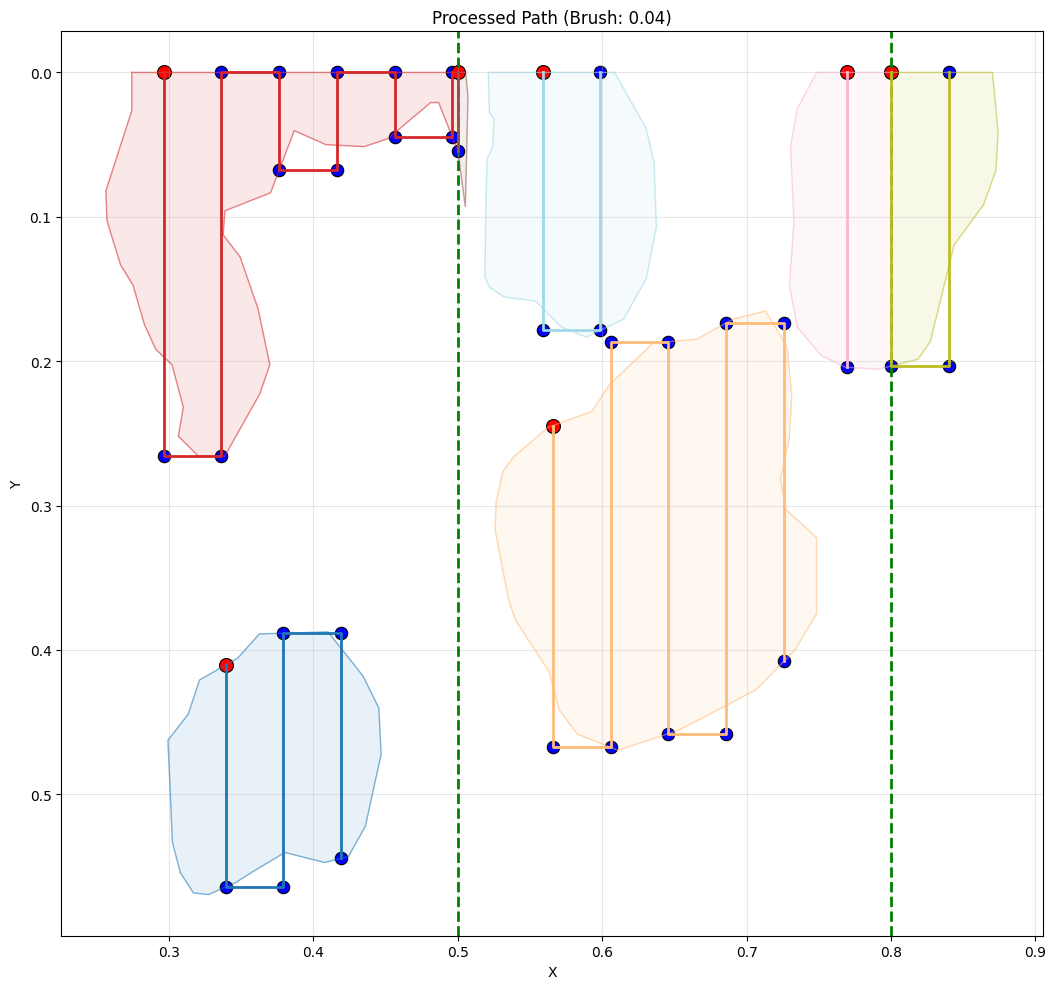

1 Left 6 0.04 (0.339;0.410) (0.339;0.564) (0.379;0.564) (0.379;0.388) (0.419;0.388) (0.419;0.544)
2 Middle 10 0.04 (0.566;0.245) (0.566;0.467) (0.606;0.467) (0.606;0.187) (0.646;0.187) (0.646;0.458) (0.686;0.458) (0.686;0.174) (0.726;0.174) (0.726;0.408)
3 Left 12 0.04 (0.296;0.000) (0.296;0.266) (0.336;0.266) (0.336;0.000) (0.376;0.000) (0.376;0.068) (0.416;0.068) (0.416;0.000) (0.456;0.000) (0.456;0.045) (0.496;0.045) (0.496;0.000)
4 Middle 2 0.04 (0.500;0.000) (0.500;0.054)
5 Middle 2 0.04 (0.770;0.000) (0.770;0.204)
6 Right 4 0.04 (0.800;0.000) (0.800;0.203) (0.840;0.203) (0.840;0.000)
7 Middle 4 0.04 (0.559;0.000) (0.559;0.179) (0.599;0.179) (0.599;0.000)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split

def unique_points(points):
    seen = set()
    return [p for p in points if not (p in seen or seen.add(p))]

def process_coordinates(path):
    x = 0
    if not path:
        return []
    
    path = unique_points(path)
    processed = [path[0]]
    
    for i in range(1, len(path), 2):
        if i + 1 >= len(path):
            processed.append(path[i])
            break
            
        point1, point2 = path[i], path[i + 1]
        x += 1
        
        if x % 2 == 1:
            y_val = point1[1] if point1[1] > point2[1] else point2[1]
            processed.extend([(point1[0], y_val), (point2[0], y_val)])
        else:
            y_val = point1[1] if point1[1] < point2[1] else point2[1]
            processed.extend([(point1[0], y_val), (point2[0], y_val)])
    
    return processed

def parse_data(file_path):
    polygons = []
    current_polygon = []
    
    with open(file_path, 'r') as file:
        for line in file:
            if not line.strip(): continue
            data = line.strip().split()[1:]
            if not data: continue
            
            coords = list(map(float, data))
            current_polygon.extend(zip(coords[::2], coords[1::2]))
            
            if line.startswith('0'):
                if current_polygon:
                    polygons.append(Polygon(current_polygon))
                    current_polygon = []
    
    if current_polygon:
        polygons.append(Polygon(current_polygon))
    
    return polygons

def create_vertical_lines(polygon, brush_radius):
    minx, miny, maxx, maxy = polygon.bounds
    lines = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += brush_radius
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                lines.append(geom)
        elif intersection.geom_type == 'LineString':
            lines.append(intersection)
        x += brush_radius
    return lines

def split_polygon_with_lines(polygon):
    split_lines = [
        LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
        LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])
    ]
    
    result = [polygon]
    
    for split_line in split_lines:
        temp = []
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def generate_snake_path(points, brush_radius):
    if len(points) < 2:
        return []
    
    points = unique_points(points)
    
    upper = []
    lower = []
    for i in range(0, len(points), 2):
        if i+1 < len(points):
            lower.append(points[i])
            upper.append(points[i+1])
    
    path = []
    for i in range(len(upper)):
        if i % 2 == 0:
            path.append(lower[i])
            path.append(upper[i])
        else:
            path.append(upper[i])
            path.append(lower[i])
        
        if i < len(upper)-1:
            if i % 2 == 0:
                path.append((upper[i][0], upper[i][1]))
            else:
                path.append((lower[i][0], lower[i][1]))
    
    return path
    
def process_polygons(polygons, brush_radius):
    all_new_points = []
    split_polygons = []
    
    for polygon in polygons:
        split_polygons.extend(split_polygon_with_lines(polygon))
    
    for polygon_idx, polygon in enumerate(split_polygons):
        lines = create_vertical_lines(polygon, brush_radius)
        points = []
        
        for line in lines:
            coords = list(line.coords)
            points.extend(coords)
        
        if not points:
            continue
            
        grouped = {}
        for x, y in points:
            if x not in grouped:
                grouped[x] = []
            grouped[x].append(y)
        
        vertical_points = []
        for x in sorted(grouped.keys()):
            ys = sorted(grouped[x])
            vertical_points.append((x, ys[0]))
            vertical_points.append((x, ys[-1]))
        
        section = determine_section(polygon)
        all_new_points.append((section, polygon_idx + 1, vertical_points))
    
    return split_polygons, all_new_points
def plot_results(polygons, brush_radius, new_points_data):
    fig, ax = plt.subplots(figsize=(14, 10))
    colors = plt.get_cmap('tab20', len(polygons))  # Обновленная строка
    
    for i, polygon in enumerate(polygons):
        if polygon.geom_type == 'Polygon' and not polygon.is_empty:
            x, y = polygon.exterior.xy
            ax.plot(x, y, color=colors(i), linewidth=1, alpha=0.5)
            ax.fill(x, y, color=colors(i), alpha=0.1)
    
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8, color='green', linestyle='--', linewidth=2)
    
    for i, (section, poly_idx, points) in enumerate(new_points_data):
        if not points: continue
        
        original_path = generate_snake_path(points, brush_radius)
        processed_path = process_coordinates(original_path)
        
        if len(processed_path) > 1:
            x, y = zip(*processed_path)
            ax.plot(x, y, color=colors(i), linestyle='-', linewidth=2)
        
        for j, (x_p, y_p) in enumerate(processed_path):
            color = 'red' if j == 0 else 'blue'
            ax.scatter(x_p, y_p, color=color, s=100 if j == 0 else 80,
                       marker='o', edgecolors='black', linewidths=0.8)
    
    ax.set_aspect('equal')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Processed Path (Brush: {brush_radius})')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Основной код
file_path = '/home/ubuntu22/Desktop/Oceanos_work/NN_gals/example_lables/f1_2743_jpg.rf.ec3e5370fe50a1bbfc33efd0626dcd8e.txt'
polygons = parse_data(file_path)
brush_radius = float(input("Радиус щётки (например 0.1): "))

split_polygons, new_points_data = process_polygons(polygons, brush_radius)

if split_polygons:
    plot_results(split_polygons, brush_radius, new_points_data)
    
    for section, poly_idx, points in new_points_data:
        original_path = generate_snake_path(points, brush_radius)
        if not original_path: continue
        
        processed_path = process_coordinates(original_path)
        coords_str = " ".join(f"({x:.3f};{y:.3f})" for x, y in processed_path)
        print(f"{poly_idx} {section} {len(processed_path)} {brush_radius} {coords_str}")
else:
    print("Нет полигонов для отображения")

Creating colored polygons plot...


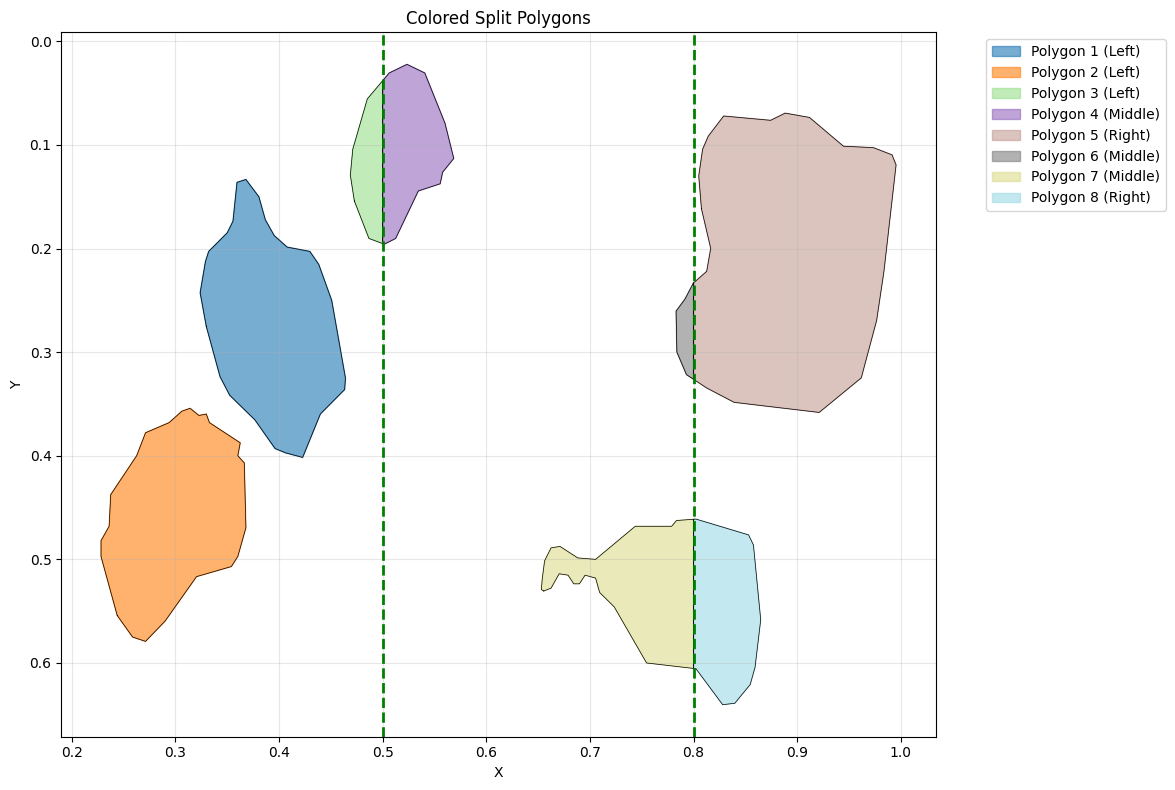

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split
from matplotlib.colors import ListedColormap

def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]  # Удаляем первый элемент
        if not data:  # Если строка пустая, пропускаем
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))  # Пара (x, y)

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_halses(polygon, spacing):
    minx, miny, maxx, maxy = polygon.bounds
    halses = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += spacing
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                halses.append(geom)
        elif intersection.geom_type == 'LineString':
            halses.append(intersection)
        x += spacing
    return halses

def split_polygon_with_lines(polygon):
    split_lines = [
        LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
        LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])
    ]
    
    result = [polygon]
    
    for split_line in split_lines:
        temp = []
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    # Фильтруем только непустые полигоны
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def plot_colored_polygons(polygons):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Создаем цветовую карту
    colors = plt.cm.tab20(np.linspace(0, 1, len(polygons)))
    
    for i, polygon in enumerate(polygons):
        x, y = polygon.exterior.xy
        ax.fill(x, y, color=colors[i], alpha=0.6, label=f'Polygon {i+1} ({determine_section(polygon)})')
        ax.plot(x, y, color='black', linewidth=0.5)
    
    # Разделительные линии
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8, color='green', linestyle='--', linewidth=2)
    
    ax.set_aspect('equal')
    plt.title('Colored Split Polygons')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Основной код
file_path = '/home/ubuntu22/Desktop/Oceanos_work/NN_gals/example_lables/f2_123_jpg.rf.35c54a8ea5489fdd626afe146ae221f2.txt'
polygons = parse_data(file_path)

# Разделяем полигоны
split_polygons = []
for polygon in polygons:
    split_polygons.extend(split_polygon_with_lines(polygon))

# Создаем график с цветными полигонами
if split_polygons:
    print("Creating colored polygons plot...")
    plot_colored_polygons(split_polygons)
else:
    print("No polygons to display!")